# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


✍️ Comentario:

La columna city presenta 469 valores nulos, equivalentes aproximadamente al 1,17 % de los registros totales. Debido a que representa una proporción muy pequeña del conjunto de datos, estos valores pueden mantenerse como nulos, ya que su ausencia no debería afectar significativamente el análisis.

Por otro lado, la columna churn_date contiene 3.534 valores nulos, equivalentes aproximadamente al 88,3 % de los registros. En este caso, los valores nulos no necesariamente representan datos faltantes que deban imputarse, sino que pueden indicar que el usuario no ha abandonado el servicio. Por esta razón, no se recomienda realizar una imputación y se conservarán los valores nulos para el análisis.

In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ Comentario:

La columna date presenta 50 valores nulos, que representan aproximadamente el 0,125 % de los registros totales. Debido a que se trata de una proporción muy pequeña, estos valores podrían mantenerse como nulos sin afectar significativamente el análisis.

La columna duration presenta 22.076 valores nulos, equivalentes aproximadamente al 55,2 % de los registros. Sin embargo, estos valores deben analizarse en función de la columna type, ya que la ausencia de duration podría estar relacionada con el tipo de registro. Por ejemplo, los registros de tipo call deberían contener información sobre la duración de la llamada, mientras que los registros de tipo text podrían no requerir este dato.

Por esta razón, antes de decidir si es necesario imputar o eliminar los valores nulos, se debe realizar un análisis cruzado entre type y las columnas duration y length, verificando si existen registros de tipo call con duration nulo o registros de tipo text con length nulo.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[[ "user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id funciona como un identificador único de los registros. En los 4.000 registros analizados, los identificadores comienzan en 10000 y terminan en 13999. Debido a que esta columna cumple una función de identificación y no representa una variable con significado analítico o matemático, no es necesario realizar un análisis estadístico sobre sus valores.

En la columna age, se observa que el promedio de edad es de 33,7 años, con un valor mínimo de -999 y un máximo de 79 años. El valor -999 no representa una edad válida, por lo que podría corresponder a un valor centinela utilizado para representar información desconocida o faltante. Este valor debe investigarse y tratarse antes de realizar el análisis estadístico definitivo.

Además, la desviación estándar es de aproximadamente 123 años, un valor considerablemente superior al promedio de edad. Esto sugiere que existen valores atípicos o inconsistencias que están afectando la distribución. Por lo tanto, no sería adecuado interpretar este valor como una variabilidad real de las edades hasta realizar la limpieza del valor centinela y volver a calcular las estadísticas descriptivas.

In [13]:
# explorar columnas numéricas de usage
usage[[ "id","user_id","duration","length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


✍️ Comentario:

Las columnas id y user_id cumplen funciones de identificación y relación entre tablas. En los 40.000 registros, la columna id presenta una secuencia que inicia en 1, mientras que user_id permite relacionar los registros con la tabla de usuarios. No se evidencian, a primera vista, valores anómalos en estas columnas, por lo que no requieren un análisis estadístico adicional. Sin embargo, posteriormente se puede validar la existencia de duplicados o user_id que no tengan correspondencia en la tabla de usuarios.
La columna duration presenta 17.924 valores no nulos. La duración promedio es de 5,2 unidades de tiempo y su desviación estándar es de 6,8. El valor mínimo es 0 y el máximo 120. Estos valores no presentan inconsistencias evidentes dentro de los registros no nulos; sin embargo, antes de interpretar la unidad como minutos, es necesario confirmarla con el contexto o la documentación del dataset. También será necesario analizar estos valores en conjunto con la columna type para determinar si los registros donde duration es nulo corresponden a mensajes de texto y, por tanto, la ausencia del dato es esperada.
La columna length presenta 22.104 valores no nulos, con un promedio de 52,1 unidades y una desviación estándar de 56,6. El valor mínimo es 0 y el máximo es 1.490. Aunque no se puede determinar únicamente con estas estadísticas que exista un error, la diferencia entre el promedio y el valor máximo indica que sería conveniente realizar una revisión adicional de los valores extremos para determinar si corresponden a valores atípicos reales o a inconsistencias en los datos. Al igual que duration, esta variable debe analizarse teniendo en cuenta la columna type.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


✍️ Comentario:

La columna city presenta 3.531 valores no nulos, equivalentes al 88,3 % de los registros. Se identifican 7 ciudades diferentes, siendo Bogotá la ciudad con mayor cantidad de registros, con 808 usuarios, equivalentes aproximadamente al 20,2 % del total de registros. La presencia de valores nulos deberá analizarse posteriormente para determinar si corresponde a información faltante o si existe algún patrón relacionado con otras variables.
La columna plan presenta 4.000 valores no nulos, por lo que cuenta con información para el 100 % de los registros y no requiere tratamiento de valores faltantes. El plan Básico es el predominante, con 2.595 registros, equivalentes aproximadamente al 64,9 % del total. Esto indica una clara concentración de usuarios en este tipo de plan.

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

✍️ Comentario:

La columna type presenta 40.000 registros no nulos, correspondientes al 100 % de los datos, por lo que no requiere tratamiento de valores faltantes. Se identifican 2 tipos de registro: call y text, siendo text el más predominante con 22.092 registros, equivalentes aproximadamente al 55,2 % del total. Esto indica una ligera predominancia de los registros de tipo texto frente a las llamadas.

✍️ Comentario:

Durante la revisión de los datos se identificó un posible valor centinela en la columna age: el valor -999, que no representa una edad válida y probablemente se utiliza para indicar un dato desconocido o faltante.

Como acción, se recomienda reemplazar -999 por un valor nulo (NaN) y posteriormente aplicar el tratamiento correspondiente a los datos faltantes. Antes de realizar la imputación, es necesario determinar si existen otros valores centinela en la columna y evaluar la distribución de las edades válidas.

En las demás columnas analizadas no se identificaron valores inválidos evidentes. Sin embargo, variables como duration y length requieren un análisis adicional de valores extremos y su relación con la columna type, para determinar si los valores observados corresponden al comportamiento esperado de cada tipo de registro.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

La columna reg_date presenta 4.000 registros no nulos, por lo que no se evidencian valores faltantes. La fecha con mayor frecuencia es 2026-05-10, con 40 registros. El período registrado comprende desde 2022-01-01 hasta 2026-05-10.
No se evidencia información de hora en los registros, por lo que la variable contiene únicamente fecha y no fecha-hora. Por esta razón, no sería necesario conservar o analizar un componente de tiempo dentro de esta columna.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

En date se evidencian 39.950 registros no nulos de un total de 40.000, con 39.950 valores únicos. Esto se debe a que la columna también almacena la hora, haciendo que cada combinación de fecha y hora sea diferente.
La primera fecha registrada es 2024-01-01 00:00:00 y la última es 2024-06-30 00:00:00. En ambos casos, la hora registrada es 00:00:00, lo cual puede considerarse un valor poco habitual, aunque no necesariamente inválido.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].mean()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       47.939922
std        17.769214
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?", np.nan)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"] > pd.Timestamp.today(), "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:

# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

In [25]:
#aplico un analisis de tablas cruzadas para tener mas claridad de los datos
pd.crosstab(usage["type"], usage["duration"].isna())

duration,False,True
type,,
call,17908,0
text,16,22076


In [26]:
#aplico un analisis de tablas cruzadas para tener mas claridad de los datos
pd.crosstab(usage["type"], usage["length"].isna())


length,False,True
type,,
call,12,17896
text,22092,0


In [27]:
# duration no debería tener valor cuando type = text
usage.loc[usage["type"] == "text", "duration"] = np.nan

# length no debería tener valor cuando type = call
usage.loc[usage["type"] == "call", "length"] = np.nan

Los valores nulos de duration y length están relacionados con el tipo de registro. Los registros call deben contener información de duración, mientras que los registros text deben contener información sobre la longitud del mensaje. Se identificaron 16 registros text con valores en duration y 12 registros call con valores en length, los cuales no corresponden al comportamiento esperado. Estos valores serán convertidos a NaN, mientras que los valores nulos que corresponden al tipo de registro se conservarán como tales.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration","length"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada","length":"longitud_mensajes_total"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada","longitud_mensajes_total"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,47.942157,5.524381,4.478120,22.836934,283.656914
std,17.770873,2.358416,2.144238,16.590213,161.877461
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000,183.000000
50%,47.000000,5.000000,4.000000,19.740000,267.000000
75%,63.000000,7.000000,6.000000,31.185000,360.000000
max,79.000000,17.000000,15.000000,155.690000,2007.000000


In [32]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

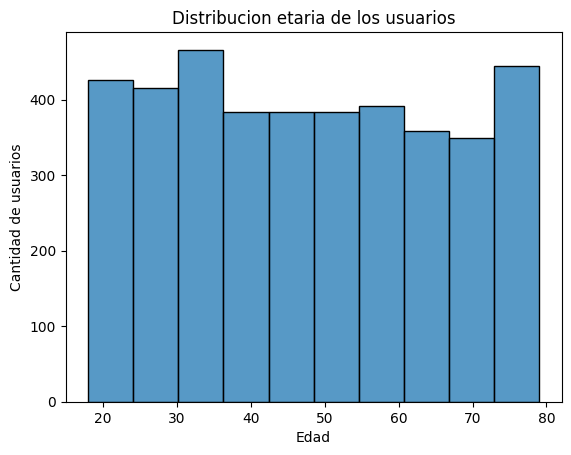

In [33]:

# Histograma para visualizar la edad (age)
sn.histplot(data=user_profile["age"],bins=10,palette=['skyblue','green'])
plt.title('Distribucion etaria de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡 Insight:
Los usuarios presentan edades entre 18 y 79 años. La frecuencia de usuarios muestra una tendencia descendente a medida que aumenta la edad hasta el rango cercano a los 70 años; posteriormente, se observa un incremento considerable. Este comportamiento podría indicar una mayor concentración de usuarios en determinados grupos etarios y debería analizarse junto con otras variables para identificar posibles patrones.

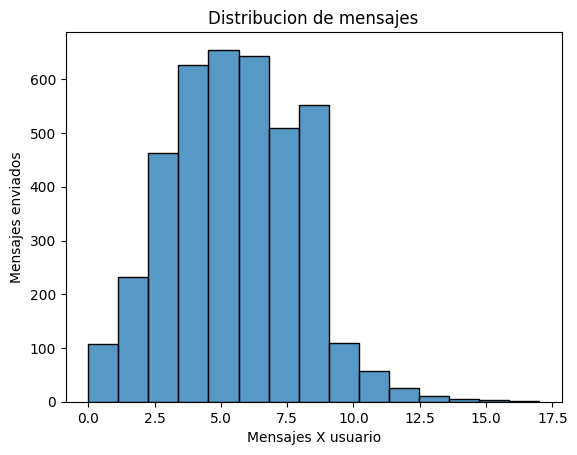

In [48]:
# Histograma para visualizar la cant_mensajes

sn.histplot(data=user_profile["cant_mensajes"],bins=15,palette=['skyblue','green'])
plt.title('Distribucion de mensajes')
plt.xlabel('Mensajes X usuario')
plt.ylabel('Mensajes enviados')
plt.show()



💡 Insights:
Se evidencia una distribución con sesgo hacia la derecha, donde la mayor proporción de uso de mensajes se concentra entre 0 y 8 mensajes por cliente. A partir de este rango, la frecuencia comienza a disminuir progresivamente.

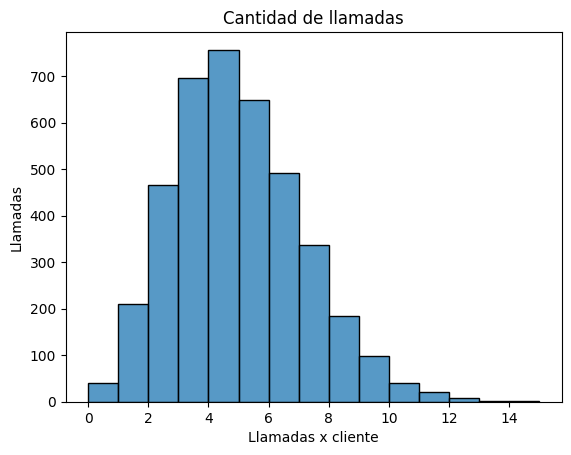

In [35]:
# Histograma para visualizar la cant_llamadas
sn.histplot(data=user_profile["cant_llamadas"],bins=15,palette=['skyblue','green'])
plt.title('Cantidad de llamadas')
plt.xlabel('Llamadas x cliente')
plt.ylabel('Llamadas')
plt.show()


💡 Insights:
Se evidencia una distribución casi de campana, con un ligero sesgo hacia la derecha. La cantidad de llamadas por cliente aumenta gradualmente hasta alcanzar su punto máximo entre 4 y 6 llamadas, a partir de donde comienza a disminuir progresivamente. Sin embargo, la cola derecha se extiende, con algunos casos de usuarios que realizan hasta 14 llamadas.

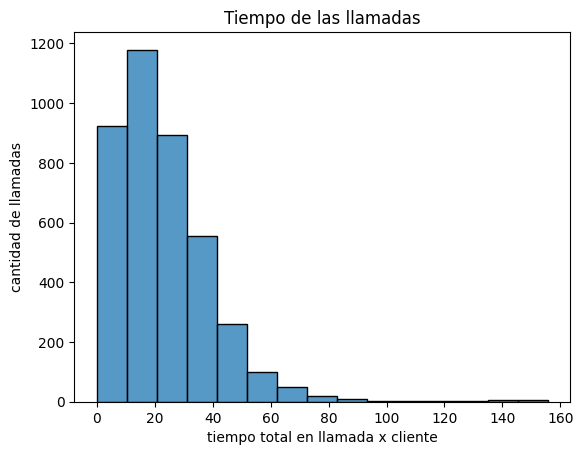

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sn.histplot(data=user_profile["cant_minutos_llamada"],bins=15,palette=['skyblue','green'])
plt.title('Tiempo de las llamadas')
plt.xlabel('tiempo total en llamada x cliente')
plt.ylabel('cantidad de llamadas')
plt.show()

Insights:

En la cantidad de tiempo por llamada se observa una distribución sesgada hacia la derecha, donde la gran mayoría de las llamadas tiene una duración de entre 0 y 30 unidades de tiempo, con una frecuencia de aproximadamente 900 a 1.200 llamadas en este rango. A partir de este punto, la frecuencia comienza a disminuir de manera abrupta y, después de las 80 unidades de tiempo, son pocos los casos de llamadas que superan esta duración.

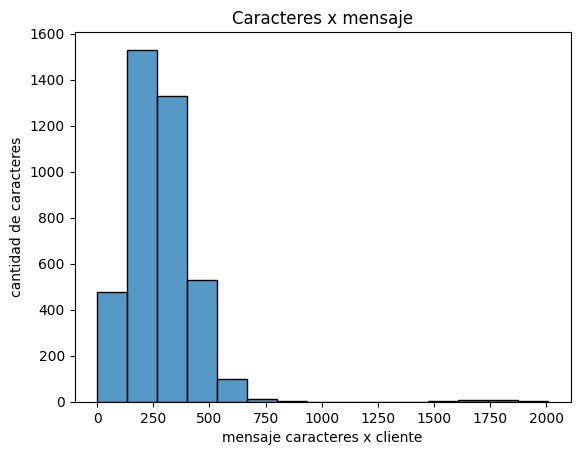

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sn.histplot(data=user_profile["longitud_mensajes_total"],bins=15,palette=['skyblue','green'])
plt.title('Caracteres x mensaje')
plt.xlabel('mensaje caracteres x cliente')
plt.ylabel('cantidad de caracteres')
plt.show()

💡 Insights:
Se consideró agregar la columna de total de caracteres por cliente, ya que conocer la cantidad de caracteres enviados por mensaje permite obtener una visión más profunda sobre el uso de los mensajes. Se observa una distribución con una pequeña forma de campana entre 0 y 760 caracteres, con un máximo aproximado de 1.600 registros alrededor de los 250 caracteres. El gráfico presenta un sesgo hacia la derecha, donde, a partir de los 750 caracteres, son pocos los usuarios que superan esta cantidad de caracteres utilizados en sus mensajes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

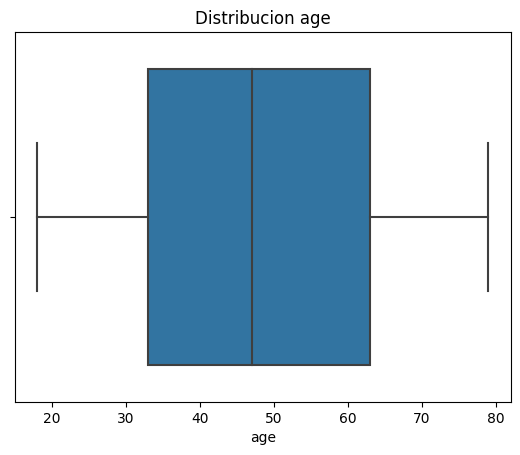

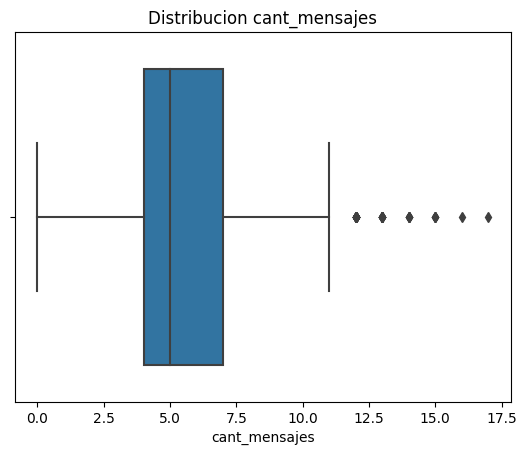

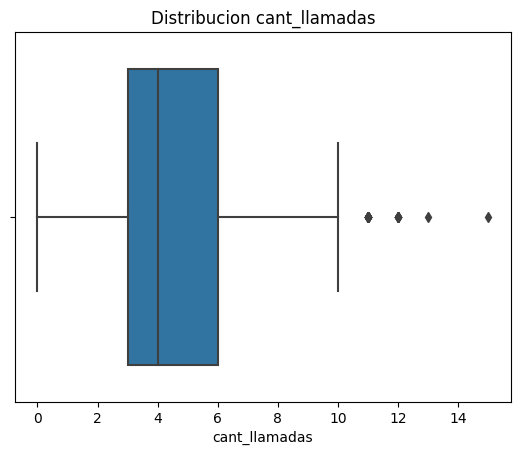

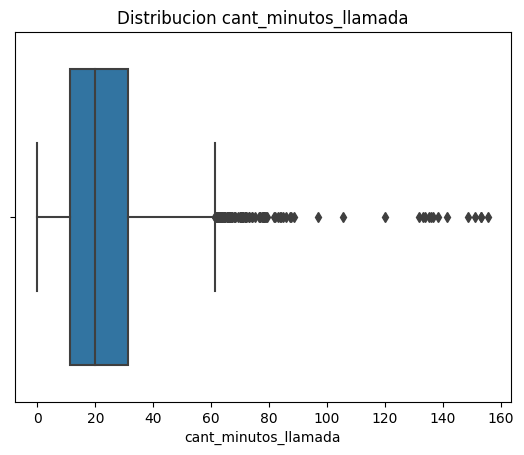

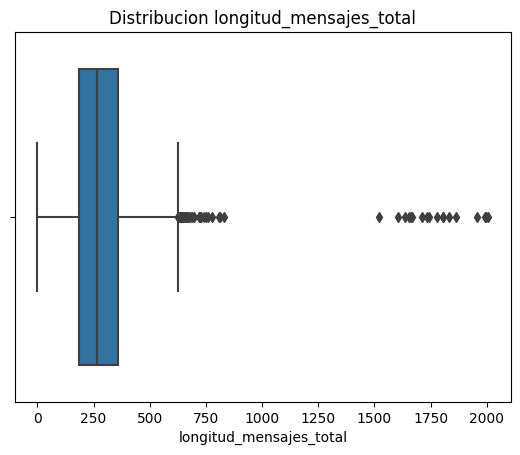

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada','longitud_mensajes_total']

for cn in columnas_numericas:
    sn.boxplot(user_profile[cn], x='value')
    plt.title('Distribucion ' + cn)
    plt.show() 

💡 Insights:

- Age: La distribución de edad presenta la mayor concentración de clientes entre los 33 y 63 años. Los bigotes se extienden desde los 18 hasta los 79 años, sin evidenciar valores atípicos. Aunque existe una amplitud considerable en las edades, la distribución no presenta outliers.
- cant_mensajes: La mayor concentración de clientes se encuentra entre 4 y 7,5 mensajes. Los bigotes se extienden desde 0 hasta 11 mensajes, a partir de donde se identifican aproximadamente 6 valores atípicos, con cantidades entre 11,5 y 17 mensajes.
- cant_llamadas: La mayor concentración de clientes se encuentra entre 3 y 6 llamadas. Los bigotes se extienden desde 0 hasta 10 llamadas, a partir de donde se identifican 4 valores atípicos, con cantidades entre 11 y 15 llamadas.
- cant_minutos_llamada: La mayor concentración de clientes se encuentra entre 10 y 30 unidades de tiempo. Los bigotes se extienden desde 0 hasta 65 unidades, a partir de donde se observa una cantidad considerable de valores atípicos.
- longitud_mensajes_total: Presenta una concentración mayoritaria de clientes entre aproximadamente 200 y 300 caracteres. Los bigotes se extienden desde 0 hasta 600 caracteres, a partir de donde comienzan a identificarse valores atípicos. Se observa un comportamiento particular: entre 600 y 800 caracteres aparecen varios outliers, mientras que entre 800 y 1.500 caracteres no se observan valores atípicos adicionales. Finalmente, aparecen nuevamente valores hasta alcanzar aproximadamente los 2.000 caracteres.

In [39]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada',"longitud_mensajes_total"]

for cl in columnas_limites:
    Q1 = user_profile[cl].quantile(0.25)
    Q3 = user_profile[cl].quantile(0.75)
    IQR = Q3 - Q1

    print(cl , "Q1:" , Q1 , ", Q3: " , Q3 , ", IQR: " , IQR)

    

age Q1: 33.0 , Q3:  63.0 , IQR:  30.0
cant_mensajes Q1: 4.0 , Q3:  7.0 , IQR:  3.0
cant_llamadas Q1: 3.0 , Q3:  6.0 , IQR:  3.0
cant_minutos_llamada Q1: 11.094999999999999 , Q3:  31.185 , IQR:  20.09
longitud_mensajes_total Q1: 183.0 , Q3:  360.0 , IQR:  177.0


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,47.942157,5.524381,4.478120,22.836934,283.656914
std,17.770873,2.358416,2.144238,16.590213,161.877461
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000,183.000000
50%,47.000000,5.000000,4.000000,19.740000,267.000000
75%,63.000000,7.000000,6.000000,31.185000,360.000000
max,79.000000,17.000000,15.000000,155.690000,2007.000000


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile["longitud_mensajes_total"].describe()

count    3999.000000
mean      283.656914
std       161.877461
min         0.000000
25%       183.000000
50%       267.000000
75%       360.000000
max      2007.000000
Name: longitud_mensajes_total, dtype: float64

💡 Insights:

- cant_mensajes: Mantener los valores atípicos. Aunque la mayoría de los clientes se encuentra entre 4 y 7 mensajes, existen usuarios que llegan hasta 17 mensajes. Estos valores pueden representar un comportamiento real de usuarios con mayor actividad y no necesariamente errores en los datos.
- cant_llamadas: Mantener los valores atípicos. La mayoría de los clientes realiza entre 3 y 6 llamadas, pero algunos llegan hasta 15. Estos valores pueden corresponder a usuarios con un mayor uso del servicio, por lo que eliminarlos podría afectar el análisis del comportamiento real de los clientes.
- cant_minutos_llamada: Mantener los valores atípicos. Aunque la mayor concentración se encuentra entre aproximadamente 11 y 31 minutos, existen usuarios con hasta 155,69 minutos de llamadas. Estos valores pueden representar clientes con un uso considerablemente mayor del servicio y no se observa evidencia suficiente para considerarlos errores.
- longitud_mensajes_total: La variable que por iniciativa decidi integrar, presenta una distribución con valores atípicos superiores a aproximadamente 625 caracteres, según la regla del IQR. Aunque existen valores considerablemente superiores a la mediana de 267 caracteres, se considera conveniente mantenerlos, ya que pueden representar clientes con un uso elevado de mensajes y eliminarlos no representaria ninguna perdida ni diferencia significativa para el analisis final

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:

# Crear columna grupo_uso
def classify_group(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
 
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(classify_group, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
def classify_group(row):
    edad = row['age']
 
    if edad < 30:
        return "Joven"
    elif edad < 60 :
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(classify_group, axis=1)

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,longitud_mensajes_total,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

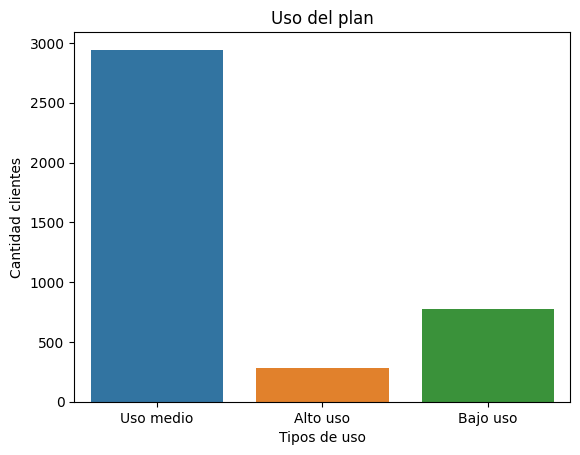

In [49]:

# Visualización de los segmentos por uso
sn.countplot(x="grupo_uso",data=user_profile)
plt.title('Uso del plan')
plt.xlabel('Tipos de uso')
plt.ylabel('Cantidad clientes')
plt.show()


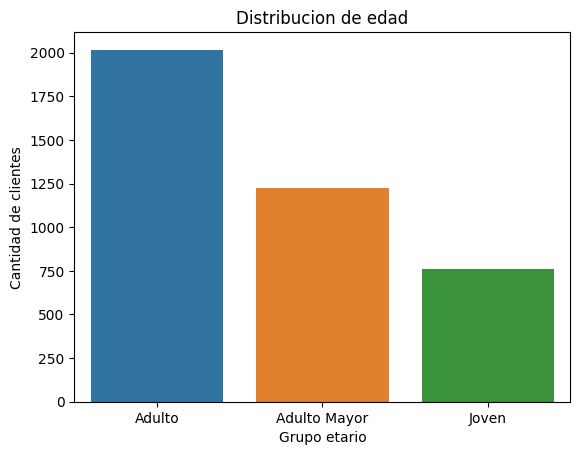

In [50]:
# Visualización de los segmentos por edad
sn.countplot(x="grupo_edad",data=user_profile)
plt.title('Distribucion de edad')
plt.xlabel('Grupo etario')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Primero, se realizó un análisis exploratorio de los tipos de datos presentes en las columnas, identificando que las columnas de fecha debían ser formateadas correctamente. Posteriormente, se elaboraron resúmenes estadísticos para comprender el comportamiento de las variables, la estructura de las tablas y la relación entre ellas. Durante este proceso, se identificaron valores nulos y valores centinela que debían ser tratados antes de continuar con el análisis.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron las columnas date de la tabla usage y reg_date de la tabla users como variables de tipo fecha, por lo que fueron formateadas correctamente como datos temporales.
- En la columna age de users se identificó el valor centinela -999, el cual fue corregido utilizando el promedio estadístico de la columna. En la columna city, los valores centinela representados por ? fueron reemplazados por valores nulos.
- Adicionalmente, el ejercicio requería identificar y convertir en nulos las fechas imposibles, es decir, aquellas posteriores a la fecha actual. Este procedimiento también fue realizado; sin embargo, no se encontraron fechas posteriores a la fecha actual, por lo que no tuvo ningún efecto sobre los datos.



🔍 **Segmentos por Edad**

* Se realizó una segmentación por edad, clasificando a los clientes menores de 30 años como **jóvenes**, a los clientes entre 30 y 60 años como **adultos** y a los mayores de 60 años como **adultos mayores**. Se identifica que la mayoría de los clientes pertenece al rango de 30 a 60 años, seguido por los adultos mayores de 60 años. El grupo con menor representación corresponde a los clientes menores de 30 años.

📊 **Segmentos por Nivel de Uso**

* Los clientes fueron segmentados según su cantidad de mensajes y llamadas: **uso bajo**, para quienes realizan menos de 5 mensajes o llamadas; **uso medio**, para quienes realizan entre 5 y 10; y **uso alto**, para quienes realizan más de 10. Se identifica que la mayor cantidad de usuarios presenta un **uso medio**, con aproximadamente 3.000 clientes. Le sigue el grupo de **bajo uso**, con aproximadamente 800 usuarios, mientras que el grupo de **alto uso** representa menos de 300 clientes.

➡️ **Conclusión general**

Los resultados muestran que la mayoría de los clientes, independientemente del plan que tengan contratado, presenta un nivel de uso medio de llamadas y mensajes de texto. Esto indica que el grupo predominante mantiene un nivel de comunicación que no es ni muy bajo ni muy alto. Además, el grupo etario con mayor representación corresponde a los adultos entre 30 y 60 años.

💡 **Recomendaciones**

* Conviene analizar con mayor profundidad qué tipo de plan utiliza cada grupo etario y qué nivel de uso presenta, con el fin de comprender mejor la relación entre el plan contratado y el comportamiento de los clientes. Adicionalmente, se incorporó el análisis de la cantidad total de caracteres enviados por los usuarios mediante mensajes, lo que permite obtener una visión más detallada del uso que hacen de este servicio.

* También sería conveniente analizar individualmente si cada grupo etario utiliza con mayor frecuencia los mensajes o las llamadas, para identificar diferencias en los patrones de uso y orientar de manera más específica los planes y campañas. Asimismo, conocer la cantidad de caracteres enviados permitiría comprender mejor el tipo de uso que realizan los clientes que utilizan mensajes de texto.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`